# Cross-layer EDA 02: DNA to RNA to protein

This notebook asks whether measurements at different biological layers tell a consistent story for the same gene in the same cell-line models.

## Biological idea

- **DNA copy number** asks how many copies of a gene are present.
- **Mutation data** asks whether the DNA sequence contains a recorded change.
- **RNA expression** asks how much gene message the cell produces.
- **Protein abundance** asks how much of the gene's functional product is measured.

DNA does not mechanically determine RNA or protein. Cells regulate transcription, RNA stability, translation, and protein degradation. Cross-layer agreement is therefore evidence of a plausible mechanism, while disagreement can also be biologically meaningful.

## Questions

1. Do higher copy numbers generally correspond to higher RNA expression?
2. Is RNA expression different in models carrying mutations in the same gene?
3. Does RNA abundance agree with measured protein abundance?
4. Which genes show directionally consistent copy-number, RNA, and protein relationships?
5. How much do lineage composition, missing protein values, and mixed releases change these conclusions?

## Guardrails

- Join models only with `model_id`.
- Join genes through curated gene metadata and audited identifiers, not loose text matching.
- Use only models with the required assays in each denominator.
- Treat mutation absence as a reference state only inside mutation-assayed models.
- Adjust correlations for broad lineage before interpreting them as gene-specific relationships.
- Proteomics is release-unmatched supplementary evidence, not a primary 24Q4 scoring layer.
- Correlation describes agreement; it does not prove that DNA caused RNA or protein changes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import rankdata

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', context='notebook')


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data' / 'depmap_24Q4'
PATHS = {
    'master': DATA / 'architecture' / 'model_master.csv',
    'gene_master': DATA / 'architecture' / 'gene_master.csv',
    'expression': DATA / 'derived' / 'expression_default_rna_model.csv',
    'copy_number': DATA / 'raw' / 'OmicsAbsoluteCNGene.csv',
    'mutations': DATA / 'derived' / 'mutations_default_dna_gene_summary.csv',
    'proteomics': DATA / 'supplementary' / 'proteomics_model.csv',
}

master = pd.read_csv(PATHS['master'], low_memory=False)
gene_master = pd.read_csv(PATHS['gene_master'], low_memory=False)
mutations = pd.read_csv(PATHS['mutations'], low_memory=False)
proteomics = pd.read_csv(PATHS['proteomics'], low_memory=False)

assert master['model_id'].is_unique
assert gene_master['symbol'].is_unique
assert proteomics['model_id'].is_unique

print(f'Identity spine: {len(master):,} models')
print(f'Gene master: {len(gene_master):,} approved symbols')
print(f'Mutation summaries: {len(mutations):,} model-gene rows')
print(f'Proteomics: {len(proteomics):,} models x {len(proteomics.columns)-1:,} protein features')

Identity spine: 2,105 models
Gene master: 43,839 approved symbols
Mutation summaries: 646,941 model-gene rows
Proteomics: 375 models x 12,558 protein features


## Column dictionary

| Column | Meaning | Project use |
|---|---|---|
| `model_id` | Stable DepMap identifier for one cell-line model. | Only automatic model-level join key. |
| `oncotree_lineage` | Broad cancer lineage of a model. | Used to adjust for tissue-driven differences. |
| `gene_id` | Stable gene identifier in the project gene master. | Preferred cross-table gene identity. |
| `symbol` | Approved HGNC gene symbol. | Human-readable gene label after identifier audit. |
| `expression_column` | Exact RNA matrix column selected for a gene. | Avoids ambiguous prefix matching. |
| `copy_number_column` | Exact absolute-copy-number matrix column selected for a gene. | Aligns DNA dosage with the correct gene. |
| `protein_feature` | Original proteomics column, usually UniProt accession plus symbol. | Retained as protein-source provenance. |
| `base_accession` | UniProt accession with an isoform suffix removed. | Audits protein-to-gene mapping. |
| `parsed_symbol` | Symbol printed in parentheses in a protein feature. | Cross-checks the UniProt mapping. |
| `mapping_status` | Result of the protein identifier audit. | Only strict, unambiguous mappings enter primary correlations. |
| `models_with_both` | Models with both measurements used in a correlation. | Exact statistic denominator. |
| `spearman_rho` | Rank correlation between two measurements. | Measures monotonic cross-layer agreement without assuming normal values. |
| `lineage_adjusted_rho` | Spearman correlation after subtracting each lineage median. | Reduces correlations driven only by tissue differences. |
| `models_lineage_adjusted` | Models retained in lineages meeting the minimum size. | Denominator for adjusted correlation. |
| `alteration_definition` | Rule used to classify a model as altered. | Keeps any-variant and damaging/driver-like analyses separate. |
| `altered_models` | Mutation-assayed, RNA-measured models meeting the alteration rule. | Altered-group denominator. |
| `reference_models` | Mutation-assayed, RNA-measured models not meeting the rule. | Reference-group denominator. |
| `median_rna_difference` | Altered median RNA minus reference median RNA. | Direction and size of expression shift. |
| `rank_biserial_effect` | Rank-based altered-versus-reference effect from -1 to 1. | Distribution-level effect size; positive means higher RNA in altered models. |
| `copy_rna_rho` | Copy-number versus RNA correlation on the triple-measured cohort. | First link in the DNA-RNA-protein chain. |
| `rna_protein_rho` | RNA versus protein correlation on the same triple-measured models. | Second link in the chain. |
| `copy_protein_rho` | Copy-number versus protein correlation on the same models. | Descriptive end-to-end agreement. |
| `directionally_consistent` | Both copy-RNA and RNA-protein correlations are positive. | Transparent descriptive flag, not a prediction score. |

## 1. Cohorts and biological denominators

Each question uses its own measured cohort. Requiring protein for a copy-number-to-RNA question would discard valid 24Q4 models for no biological reason.

,cohort,required_flags,models,pct_of_spine,release_scope
0,Copy number to RNA,has_absolute_copy_number + has_expression,1303,61.900238,24Q4 release matched
1,Mutation context to RNA,has_mutation_assay + has_expression,1597,75.866983,24Q4 release matched
2,RNA to protein,has_expression + has_supplementary_proteomics,370,17.577197,Mixed release: supplementary protein
3,Copy number to RNA to protein,has_absolute_copy_number + has_expression + ha...,287,13.634204,Mixed release: supplementary protein


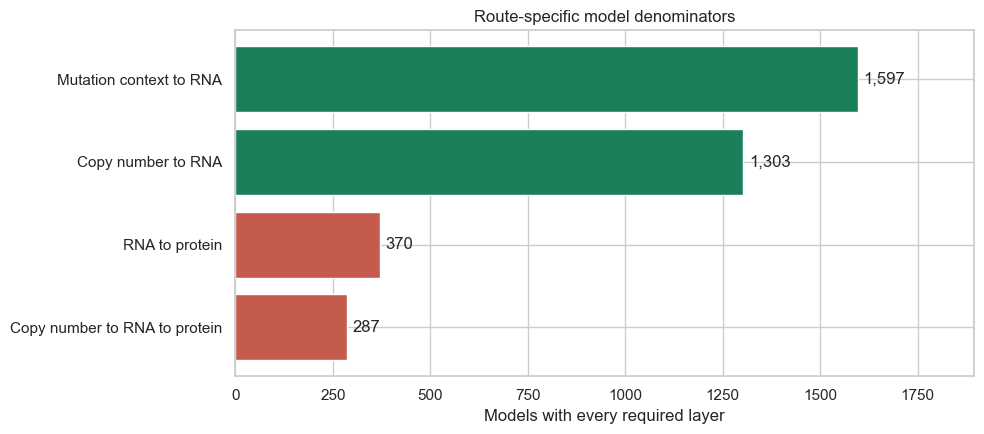

In [2]:
cohort_definitions = {
    'Copy number to RNA': ['has_absolute_copy_number', 'has_expression'],
    'Mutation context to RNA': ['has_mutation_assay', 'has_expression'],
    'RNA to protein': ['has_expression', 'has_supplementary_proteomics'],
    'Copy number to RNA to protein': ['has_absolute_copy_number', 'has_expression', 'has_supplementary_proteomics'],
}

cohort_rows = []
cohort_ids = {}
for cohort, flags in cohort_definitions.items():
    mask = master[flags].fillna(0).eq(1).all(axis=1)
    cohort_ids[cohort] = set(master.loc[mask, 'model_id'])
    cohort_rows.append({
        'cohort': cohort,
        'required_flags': ' + '.join(flags),
        'models': int(mask.sum()),
        'pct_of_spine': 100 * mask.mean(),
        'release_scope': 'Mixed release: supplementary protein' if 'has_supplementary_proteomics' in flags else '24Q4 release matched',
    })

cohort_summary = pd.DataFrame(cohort_rows)
display(cohort_summary)

fig, ax = plt.subplots(figsize=(10, 4.5))
plot_cohorts = cohort_summary.sort_values('models')
colors = ['#c45b4d' if 'Mixed' in scope else '#1b7f5a' for scope in plot_cohorts['release_scope']]
bars = ax.barh(plot_cohorts['cohort'], plot_cohorts['models'], color=colors)
for bar, count in zip(bars, plot_cohorts['models']):
    ax.text(bar.get_width() + 14, bar.get_y() + bar.get_height()/2, f'{count:,}', va='center')
ax.set_xlim(0, len(master) * 0.9)
ax.set_xlabel('Models with every required layer')
ax.set_ylabel('')
ax.set_title('Route-specific model denominators')
plt.tight_layout()
plt.show()

### What this means for the project

The copy-number-to-RNA and mutation-to-RNA analyses can use large, release-matched cohorts. Protein comparisons are much smaller and come from a supplementary release, so they are validation rather than primary scoring evidence.

**Example:** an RNA-protein result calculated from the protein panel must report that smaller denominator. It cannot inherit the 1,673-model RNA denominator simply because RNA exists for more models.

## 2. Gene and protein identifier audit

RNA and copy-number columns are taken from `gene_master`. Protein features are accepted for primary analysis only when a unique UniProt accession maps to the same approved symbol printed in the feature and only one protein feature represents that symbol.

,mapping_stage,features_or_genes
0,All proteomics features,12558
1,Unique UniProt mapping and symbol agreement,12216
2,One protein feature per approved gene with RNA,11682
3,Primary genes measured in at least 100 models,9580


,mapping_status,protein_features
0,UniProt and approved symbol agree,12216
1,No unique UniProt mapping,332
2,UniProt-symbol disagreement,10


,symbol,protein_feature,features_for_symbol
3434,ACLY,P53396 (ACLY),2
3715,ACLY,P53396-2 (ACLY),2
2017,ACTN1,P12814 (ACTN1),2
2626,ACTN1,P12814-4 (ACTN1),2
4256,AHNAK,Q09666 (AHNAK),2
4578,AHNAK,Q09666-2 (AHNAK),2
4505,ALCAM,Q13740 (ALCAM),2
4583,ALCAM,Q13740-2 (ALCAM),2
3226,ALDH7A1,P49419 (ALDH7A1),2
3635,ALDH7A1,P49419-2 (ALDH7A1),2


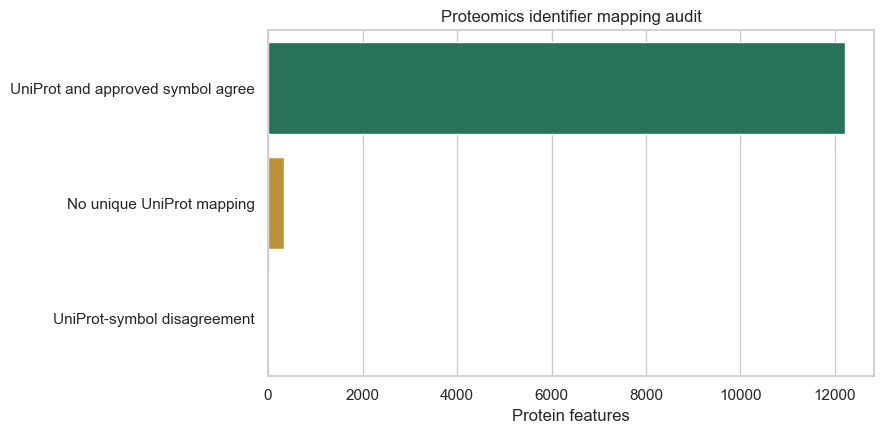

In [3]:
protein_columns = proteomics.columns[1:].tolist()
protein_map = pd.DataFrame({'protein_feature': protein_columns})
protein_map['accession'] = protein_map['protein_feature'].str.extract(r'^([^ ]+)')[0]
protein_map['base_accession'] = protein_map['accession'].str.replace(r'-[0-9]+$', '', regex=True)
protein_map['parsed_symbol'] = protein_map['protein_feature'].str.extract(r'[(]([^()]*)[)]$')[0]

uniprot_map = (
    gene_master[['gene_id', 'symbol', 'uniprot_ids']]
    .dropna(subset=['uniprot_ids'])
    .assign(base_accession=lambda d: d['uniprot_ids'].str.split('|'))
    .explode('base_accession')
)
uniprot_map['accession_is_unique'] = ~uniprot_map['base_accession'].duplicated(keep=False)
uniprot_unique = uniprot_map.loc[uniprot_map['accession_is_unique'], ['base_accession', 'gene_id', 'symbol']]

protein_map = protein_map.merge(uniprot_unique, on='base_accession', how='left')
protein_map['mapping_status'] = np.select(
    [
        protein_map['gene_id'].isna(),
        protein_map['gene_id'].notna() & protein_map['parsed_symbol'].ne(protein_map['symbol']),
    ],
    ['No unique UniProt mapping', 'UniProt-symbol disagreement'],
    default='UniProt and approved symbol agree',
)

confirmed = protein_map.loc[protein_map['mapping_status'].eq('UniProt and approved symbol agree')].copy()
confirmed['features_for_symbol'] = confirmed.groupby('symbol')['protein_feature'].transform('size')
confirmed['measured_models'] = confirmed['protein_feature'].map(proteomics[protein_columns].notna().sum())
confirmed = confirmed.merge(
    gene_master[['gene_id', 'symbol', 'expression_column', 'copy_number_column', 'is_protein_coding']],
    on=['gene_id', 'symbol'], how='left', validate='many_to_one'
)
primary_protein_map = confirmed.loc[
    confirmed['features_for_symbol'].eq(1)
    & confirmed['expression_column'].notna()
].copy()

mapping_audit = pd.DataFrame([
    {'mapping_stage': 'All proteomics features', 'features_or_genes': len(protein_map)},
    {'mapping_stage': 'Unique UniProt mapping and symbol agreement', 'features_or_genes': len(confirmed)},
    {'mapping_stage': 'One protein feature per approved gene with RNA', 'features_or_genes': len(primary_protein_map)},
    {'mapping_stage': 'Primary genes measured in at least 100 models', 'features_or_genes': int(primary_protein_map['measured_models'].ge(100).sum())},
])
display(mapping_audit)
display(protein_map['mapping_status'].value_counts().rename_axis('mapping_status').reset_index(name='protein_features'))
display(confirmed.loc[confirmed['features_for_symbol'].gt(1), ['symbol', 'protein_feature', 'features_for_symbol']].sort_values(['symbol', 'protein_feature']).head(30))

fig, ax = plt.subplots(figsize=(9, 4.5))
status_counts = protein_map['mapping_status'].value_counts().reset_index()
sns.barplot(data=status_counts, x='count', y='mapping_status', hue='mapping_status', legend=False, palette=['#1b7f5a', '#d39b24', '#c45b4d'], ax=ax)
ax.set_title('Proteomics identifier mapping audit')
ax.set_xlabel('Protein features')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### What this means for the project

Protein tables can contain separate accessions or isoforms for the same gene. Averaging them without review could combine different protein products. The primary analysis therefore uses the conservative one-feature-per-gene subset and keeps excluded features visible in the audit.

**Example:** `CDKN2A` has more than one mapped protein feature in this dataset. It remains available for later protein-specific investigation but is not silently reduced to one value in the primary RNA-protein correlation.

## 3. Reproducible analysis-gene set

A targeted but broad gene set is used so the 1 GB RNA matrix is scanned once without loading all 53,969 RNA features into memory. It combines project genes, recurrently mutated genes, well-measured proteins, and a fixed random background of protein-coding genes.

In [4]:
PROJECT_GENES = [
    'TP53', 'BRCA1', 'BRCA2', 'ARID1A', 'EZH2', 'KRAS', 'BRAF', 'PIK3CA',
    'PTEN', 'RB1', 'CDKN2A', 'MYC', 'ERBB2', 'EGFR', 'MDM2', 'CDK4', 'ALK', 'EML4'
]

mutations['damaging_event'] = mutations['has_likely_lof'].eq(1) | mutations['highest_vep_impact'].eq('HIGH')
mutations['driver_like_event'] = mutations[['has_hotspot', 'has_oncogene_high_impact', 'has_tumor_suppressor_high_impact']].eq(1).any(axis=1)
mutation_recurrence = mutations.groupby('hugo_symbol')['model_id'].nunique().sort_values(ascending=False)
recurrent_genes = mutation_recurrence.head(100).index.tolist()

well_measured_protein_pool = primary_protein_map.loc[primary_protein_map['measured_models'].ge(100), 'symbol'].drop_duplicates()
well_measured_protein = well_measured_protein_pool.sample(n=min(500, len(well_measured_protein_pool)), random_state=25).tolist()

background_pool = gene_master.loc[
    gene_master['is_protein_coding'].eq(1)
    & gene_master['expression_column'].notna()
    & gene_master['copy_number_column'].notna(),
    'symbol'
].drop_duplicates()
background_genes = background_pool.sample(n=min(500, len(background_pool)), random_state=25).tolist()

reason_sets = {
    'Project example': set(PROJECT_GENES),
    'Top 100 recurrent mutation': set(recurrent_genes),
    'Fixed sample of well-measured proteins': set(well_measured_protein),
    'Fixed protein-coding background': set(background_genes),
}
analysis_symbols = sorted(set().union(*reason_sets.values()))
analysis_gene_table = gene_master.loc[
    gene_master['symbol'].isin(analysis_symbols)
    & gene_master['expression_column'].notna()
    & gene_master['copy_number_column'].notna(),
    ['gene_id', 'symbol', 'expression_column', 'copy_number_column', 'is_protein_coding']
].copy()
analysis_gene_table['selection_reason'] = analysis_gene_table['symbol'].map(
    lambda symbol: ' | '.join(reason for reason, symbols in reason_sets.items() if symbol in symbols)
)

expression_columns = analysis_gene_table['expression_column'].drop_duplicates().tolist()
copy_columns = analysis_gene_table['copy_number_column'].drop_duplicates().tolist()
rna = pd.read_csv(PATHS['expression'], usecols=['model_id', *expression_columns])
copy_number = pd.read_csv(PATHS['copy_number'], usecols=['Unnamed: 0', *copy_columns]).rename(columns={'Unnamed: 0': 'model_id'})

expression_rename = analysis_gene_table.set_index('expression_column')['symbol'].to_dict()
copy_rename = analysis_gene_table.set_index('copy_number_column')['symbol'].to_dict()
rna = rna.rename(columns=expression_rename).set_index('model_id')
copy_number = copy_number.rename(columns=copy_rename).set_index('model_id')

assert rna.index.is_unique and copy_number.index.is_unique
assert set(rna.columns) == set(copy_number.columns) == set(analysis_gene_table['symbol'])

selection_summary = pd.DataFrame([
    {'selection_component': reason, 'requested_genes': len(symbols), 'genes_in_final_set': len(symbols & set(analysis_gene_table['symbol']))}
    for reason, symbols in reason_sets.items()
])
display(selection_summary)
print(f'Final analysis set: {len(analysis_gene_table):,} genes')
print(f'RNA subset: {rna.shape}; copy-number subset: {copy_number.shape}')
display(analysis_gene_table.head(20))

,selection_component,requested_genes,genes_in_final_set
0,Project example,18,18
1,Top 100 recurrent mutation,100,94
2,Fixed sample of well-measured proteins,500,485
3,Fixed protein-coding background,500,500


Final analysis set: 1,077 genes
RNA subset: (1673, 1077); copy-number subset: (1607, 1077)


,gene_id,symbol,expression_column,copy_number_column,is_protein_coding,selection_reason
26,HGNC:19,AANAT,AANAT (ENSG00000129673),AANAT (15),1,Fixed protein-coding background
38,HGNC:19235,AATF,AATF (ENSG00000275700),AATF (26574),1,Fixed protein-coding background
43,HGNC:29,ABCA1,ABCA1 (ENSG00000165029),ABCA1 (19),1,Fixed protein-coding background
57,HGNC:14638,ABCA13,ABCA13 (ENSG00000179869),ABCA13 (154664),1,Top 100 recurrent mutation
95,HGNC:68,ABCD4,ABCD4 (ENSG00000119688),ABCD4 (5826),1,Fixed sample of well-measured proteins
166,HGNC:82,ACAA1,ACAA1 (ENSG00000060971),ACAA1 (30),1,Fixed sample of well-measured proteins
177,HGNC:89,ACADM,ACADM (ENSG00000117054),ACADM (34),1,Fixed protein-coding background
179,HGNC:91,ACADSB,ACADSB (ENSG00000196177),ACADSB (36),1,Fixed protein-coding background
192,HGNC:23339,ACBD6,ACBD6 (ENSG00000230124),ACBD6 (84320),1,Fixed protein-coding background
239,HGNC:14376,ACP4,ACP4 (ENSG00000142513),ACP4 (93650),1,Fixed protein-coding background


### What this means for the project

This gene set is large enough to show broad behaviour but is not a claim of a complete genome-wide screen. The fixed random seed makes the background reproducible, while project and recurrent genes ensure clinically relevant examples are retained.

**Example:** a strong result for a selected cancer gene can be compared with the distribution across hundreds of background genes. Later production feature generation can apply the same audited method to any requested gene pair.

## 4. Copy number to RNA concordance

For each selected gene, absolute copy number and RNA are compared across the same models. Spearman correlation is used because both measurements can contain extreme values and their relationship need not be linear.

,count,mean,std,min,25%,50%,75%,max
models_with_both,1077.0,1303.000000,0.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000
spearman_rho,1077.0,0.180916,0.116327,-0.130997,0.096663,0.181308,0.257536,0.706954
models_lineage_adjusted,1077.0,1275.000000,0.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
lineage_adjusted_rho,1077.0,0.172644,0.106195,-0.067658,0.087471,0.168179,0.251483,0.637952


,gene,models_with_both,spearman_rho,models_lineage_adjusted,lineage_adjusted_rho
161,CDKN2A,1303,0.706954,1275,0.637952
196,CPNE1,1303,0.483367,1275,0.455579
655,OSER1,1303,0.538433,1275,0.448236
219,CUL4A,1303,0.418939,1275,0.434480
737,PSMG2,1303,0.385629,1275,0.432362
538,METTL23,1303,0.458485,1275,0.429300
293,ERGIC3,1303,0.496180,1275,0.428235
922,TARS1,1303,0.455954,1275,0.427950
797,RPS21,1303,0.330926,1275,0.425439
927,TBP,1303,0.399413,1275,0.421006


,gene,models_with_both,spearman_rho,models_lineage_adjusted,lineage_adjusted_rho
564,MS4A1,1303,-0.130997,1275,-0.067658
488,LRP1B,1303,-0.052653,1275,-0.053258
202,CRTAC1,1303,0.028756,1275,-0.045379
669,PARVG,1303,-0.109419,1275,-0.042990
664,PALM,1303,-0.057540,1275,-0.038394
960,TNFSF18,1303,0.031304,1275,-0.034402
863,SLC18A3,1303,-0.005141,1275,-0.024061
713,PNPLA5,1303,0.023281,1275,-0.022981
645,OR2F2,1303,-0.019751,1275,-0.022359
349,GFRA3,1303,0.001352,1275,-0.020361


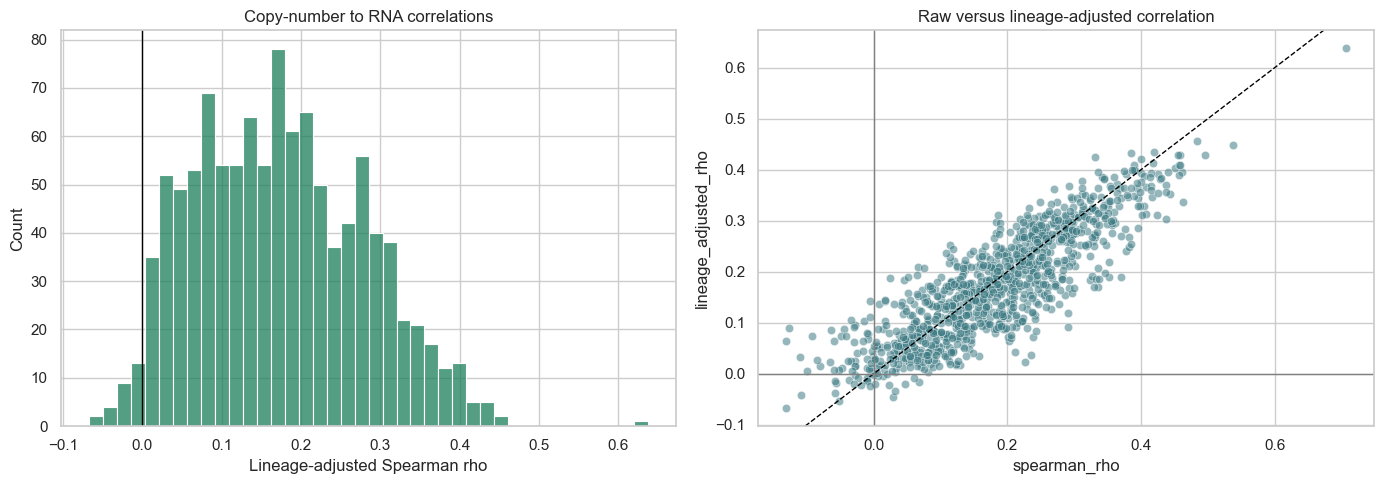

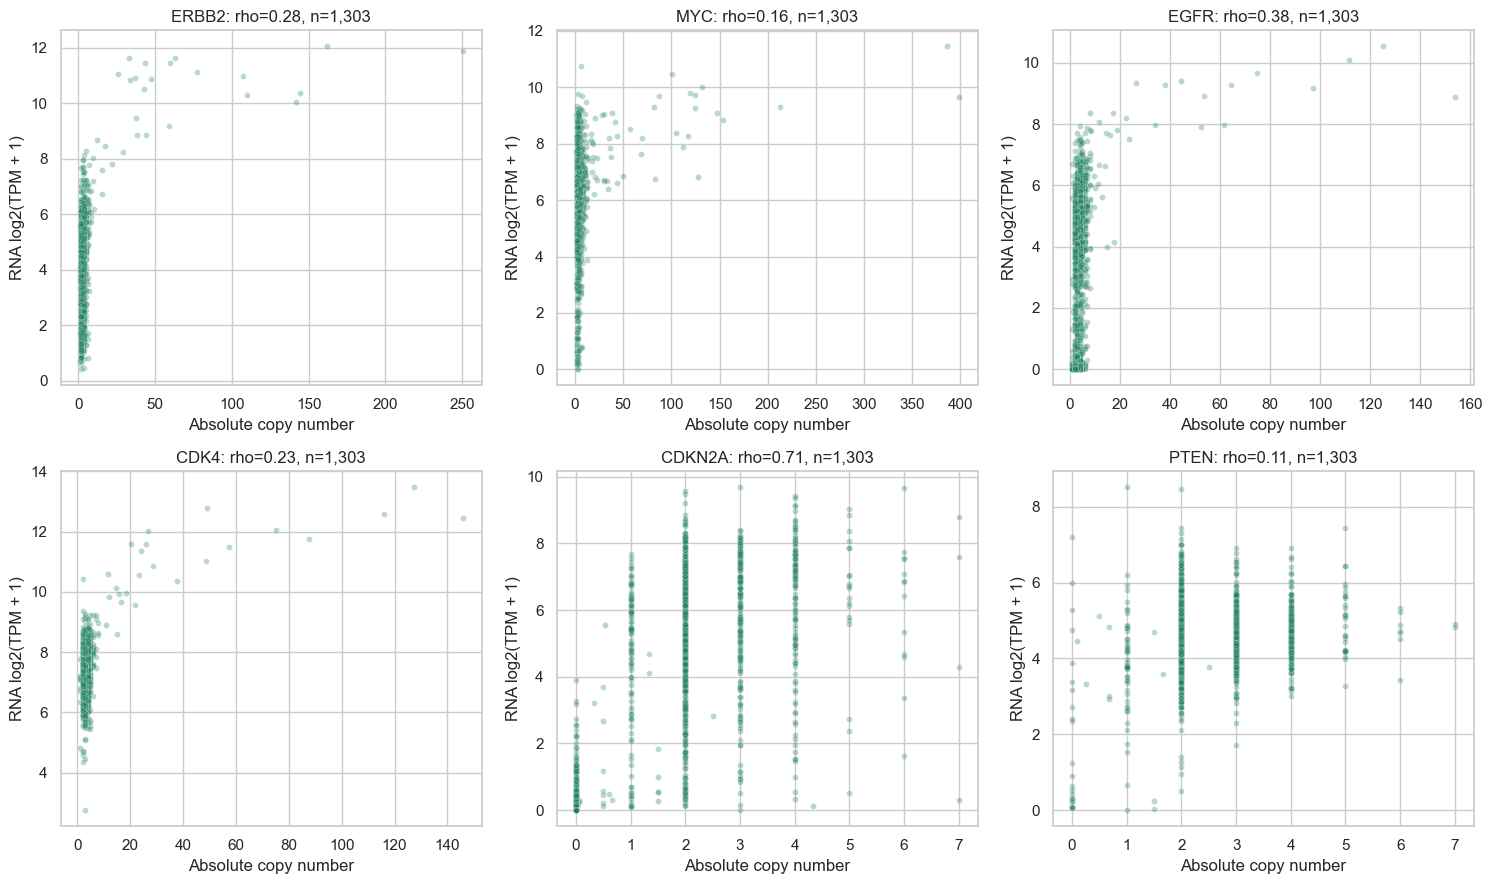

,gene,copy_state,models,median_rna
0,ERBB2,loss-like (CN <= 1),18,3.942862
1,ERBB2,near-diploid (1 < CN < 4),877,4.297191
2,ERBB2,gain-like (CN >= 4),408,4.867649
3,MYC,loss-like (CN <= 1),2,6.045948
4,MYC,near-diploid (1 < CN < 4),622,6.123086
5,MYC,gain-like (CN >= 4),679,6.295356
6,EGFR,loss-like (CN <= 1),20,0.124085
7,EGFR,near-diploid (1 < CN < 4),669,2.969012
8,EGFR,gain-like (CN >= 4),614,4.710668
9,CDK4,loss-like (CN <= 1),9,7.074570


In [5]:
lineage_lookup = master.set_index('model_id')['oncotree_lineage'].fillna('Unknown')


def correlation_with_lineage_adjustment(x: pd.Series, y: pd.Series, minimum_lineage_size: int = 15) -> dict:
    frame = pd.DataFrame({'x': x, 'y': y, 'lineage': lineage_lookup.reindex(x.index)}).dropna()
    raw_rho = frame['x'].corr(frame['y'], method='spearman') if len(frame) >= 3 else np.nan
    keep = frame.groupby('lineage')['x'].transform('size').ge(minimum_lineage_size)
    adjusted = frame.loc[keep].copy()
    if len(adjusted) >= 30:
        adjusted[['x_residual', 'y_residual']] = adjusted[['x', 'y']] - adjusted.groupby('lineage')[['x', 'y']].transform('median')
        adjusted_rho = adjusted['x_residual'].corr(adjusted['y_residual'], method='spearman')
    else:
        adjusted_rho = np.nan
    return {
        'models_with_both': len(frame),
        'spearman_rho': raw_rho,
        'models_lineage_adjusted': len(adjusted),
        'lineage_adjusted_rho': adjusted_rho,
    }


copy_rna_ids = sorted(cohort_ids['Copy number to RNA'] & set(rna.index) & set(copy_number.index))
copy_rna_rows = []
for gene in analysis_gene_table['symbol']:
    result = correlation_with_lineage_adjustment(copy_number.loc[copy_rna_ids, gene], rna.loc[copy_rna_ids, gene])
    copy_rna_rows.append({'gene': gene, **result})
copy_rna_results = pd.DataFrame(copy_rna_rows)

display(copy_rna_results[['models_with_both', 'spearman_rho', 'models_lineage_adjusted', 'lineage_adjusted_rho']].describe().T)
display(copy_rna_results.nlargest(25, 'lineage_adjusted_rho'))
display(copy_rna_results.nsmallest(25, 'lineage_adjusted_rho'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(copy_rna_results['lineage_adjusted_rho'].dropna(), bins=40, color='#1b7f5a', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Copy-number to RNA correlations')
axes[0].set_xlabel('Lineage-adjusted Spearman rho')
sns.scatterplot(data=copy_rna_results, x='spearman_rho', y='lineage_adjusted_rho', alpha=0.55, color='#3f7c85', ax=axes[1])
axes[1].axline((0, 0), slope=1, color='black', linestyle='--', linewidth=1)
axes[1].axhline(0, color='grey', linewidth=1); axes[1].axvline(0, color='grey', linewidth=1)
axes[1].set_title('Raw versus lineage-adjusted correlation')
plt.tight_layout()
plt.show()

example_copy_genes = [gene for gene in ['ERBB2', 'MYC', 'EGFR', 'CDK4', 'CDKN2A', 'PTEN'] if gene in rna.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, gene in zip(axes.flat, example_copy_genes):
    frame = pd.DataFrame({'copy_number': copy_number.loc[copy_rna_ids, gene], 'rna': rna.loc[copy_rna_ids, gene]}).dropna()
    sns.scatterplot(data=frame, x='copy_number', y='rna', alpha=0.3, s=18, color='#1b7f5a', ax=ax)
    ax.set_title(f'{gene}: rho={frame.copy_number.corr(frame.rna, method="spearman"):.2f}, n={len(frame):,}')
    ax.set_xlabel('Absolute copy number'); ax.set_ylabel('RNA log2(TPM + 1)')
for ax in axes.flat[len(example_copy_genes):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

copy_state_rows = []
for gene in example_copy_genes:
    frame = pd.DataFrame({'copy_number': copy_number.loc[copy_rna_ids, gene], 'rna': rna.loc[copy_rna_ids, gene]}).dropna()
    for state, mask in [('loss-like (CN <= 1)', frame['copy_number'].le(1)), ('near-diploid (1 < CN < 4)', frame['copy_number'].gt(1) & frame['copy_number'].lt(4)), ('gain-like (CN >= 4)', frame['copy_number'].ge(4))]:
        copy_state_rows.append({'gene': gene, 'copy_state': state, 'models': int(mask.sum()), 'median_rna': frame.loc[mask, 'rna'].median()})
display(pd.DataFrame(copy_state_rows))

### What this means for the project

A positive copy-number-to-RNA correlation means models with more copies of a gene tend to produce more RNA from that gene. The lineage-adjusted value asks whether that relationship remains after broad tissue-level expression differences are reduced.

Copy-number thresholds are descriptive examples, not universal biological cut-offs. A gene can be highly expressed without amplification, and an amplified gene can be transcriptionally silenced.

**Example:** an ERBB2 amplification mechanism is more convincing when high ERBB2 copy number and high ERBB2 RNA occur in the same models. That concordance can later support a transparent gene-pair explanation, but it does not by itself show dependency on a second gene.

## 5. Mutation context to RNA

Mutation effects are examined only among models with a mutation assay and RNA. Two definitions are kept separate: any recorded variant, and a narrower damaging-or-driver-like definition.

,gene,alteration_definition,altered_models,reference_models,median_rna_altered,median_rna_reference,median_rna_difference,rank_biserial_effect,altered_models_lineage_adjusted,reference_models_lineage_adjusted,lineage_adjusted_rank_biserial
1341,PBRM1,Damaging or driver-like,48,1549,2.528147,4.139961,-1.611814,-0.660628,47,1518,-0.626987
1103,MPHOSPH8,Damaging or driver-like,10,1587,3.547395,4.249445,-0.702051,-0.539572,10,1555,-0.616270
1753,SMARCA4,Damaging or driver-like,88,1509,4.900327,6.202418,-1.302091,-0.486852,86,1479,-0.500401
1521,RB1,Damaging or driver-like,115,1482,2.533563,4.132577,-1.599013,-0.571067,114,1451,-0.498440
304,CD74,Any recorded variant,10,1587,1.160271,2.742006,-1.581735,-0.217265,10,1555,-0.483537
571,EML4,Damaging or driver-like,10,1587,4.229928,4.478325,-0.248396,-0.279017,10,1555,-0.479293
1927,TNKS1BP1,Damaging or driver-like,12,1585,4.689287,5.381975,-0.692689,-0.457150,12,1553,-0.446179
789,HLA-C,Damaging or driver-like,12,1585,7.021134,7.762349,-0.741214,-0.396372,12,1553,-0.425306
1827,SULF2,Damaging or driver-like,12,1585,1.227627,2.861955,-1.634328,-0.300789,12,1553,-0.414520
947,LCP2,Damaging or driver-like,11,1586,0.056584,0.070389,-0.013806,0.031812,11,1554,-0.387680


,gene,alteration_definition,altered_models,reference_models,median_rna_altered,median_rna_reference,median_rna_difference,rank_biserial_effect,altered_models_lineage_adjusted,reference_models_lineage_adjusted,lineage_adjusted_rank_biserial
1178,NACC1,Any recorded variant,24,1573,5.752874,5.037382,0.715492,0.518251,23,1542,0.487622
878,INTS12,Any recorded variant,12,1585,4.624338,4.211791,0.412547,0.405994,12,1553,0.486907
1550,RHBDD3,Any recorded variant,19,1578,5.341274,4.487358,0.853917,0.595824,19,1546,0.484272
302,CD40,Any recorded variant,10,1587,3.268993,1.257011,2.011982,0.357530,10,1555,0.465466
2020,UCP3,Any recorded variant,13,1584,1.372952,0.713696,0.659256,0.401952,13,1552,0.456582
262,CAMK1,Any recorded variant,11,1586,3.432959,2.709291,0.723669,0.385647,10,1555,0.449132
1793,SPTB,Damaging or driver-like,11,1586,0.831877,0.275007,0.556870,0.318067,11,1554,0.438224
178,BCL2,Any recorded variant,26,1571,5.575413,1.350497,4.224916,0.689003,26,1539,0.437897
2142,ZNF771,Any recorded variant,19,1578,2.558268,1.827819,0.730449,0.432326,19,1546,0.436951
1870,TFB1M,Any recorded variant,19,1578,4.017031,3.465974,0.551057,0.382096,19,1546,0.430176


,gene,alteration_definition,altered_models,reference_models,median_rna_altered,median_rna_reference,median_rna_difference,rank_biserial_effect,altered_models_lineage_adjusted,reference_models_lineage_adjusted,lineage_adjusted_rank_biserial
72,ALK,Any recorded variant,95,1502,0.084064,0.056584,0.027481,0.070965,93,1472,-0.002929
73,ALK,Damaging or driver-like,18,1579,0.042576,0.056584,-0.014007,0.112835,18,1547,0.037995
110,ARID1A,Any recorded variant,217,1380,4.665620,4.724923,-0.059303,-0.041388,215,1350,-0.051053
111,ARID1A,Damaging or driver-like,152,1445,4.615887,4.729553,-0.113666,-0.070538,150,1415,-0.087939
204,BRAF,Any recorded variant,185,1412,3.187451,3.053111,0.134340,0.098051,181,1384,0.062362
205,BRAF,Damaging or driver-like,147,1450,3.209453,3.053111,0.156342,0.115599,144,1421,0.058009
206,BRCA1,Any recorded variant,81,1516,4.464015,4.339849,0.124165,0.067714,80,1485,0.098106
207,BRCA1,Damaging or driver-like,26,1571,4.351604,4.341986,0.009618,-0.057313,26,1539,0.009997
208,BRCA2,Any recorded variant,118,1479,2.631025,2.553361,0.077664,0.047295,112,1453,0.025188
209,BRCA2,Damaging or driver-like,55,1542,2.565597,2.563156,0.002441,0.007417,51,1514,-0.012511


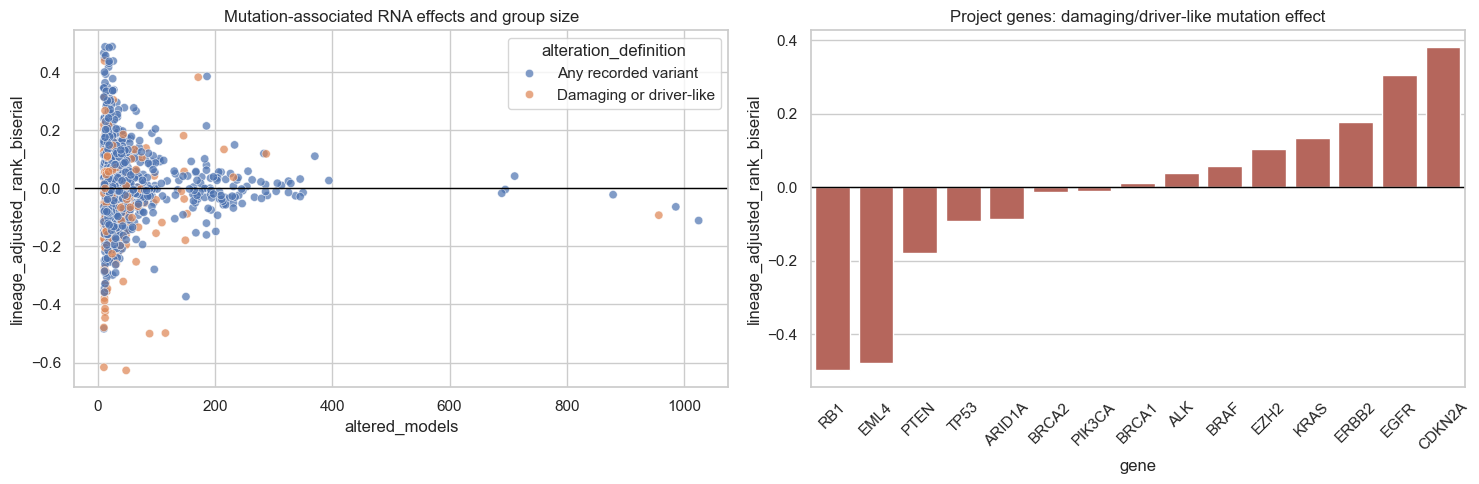

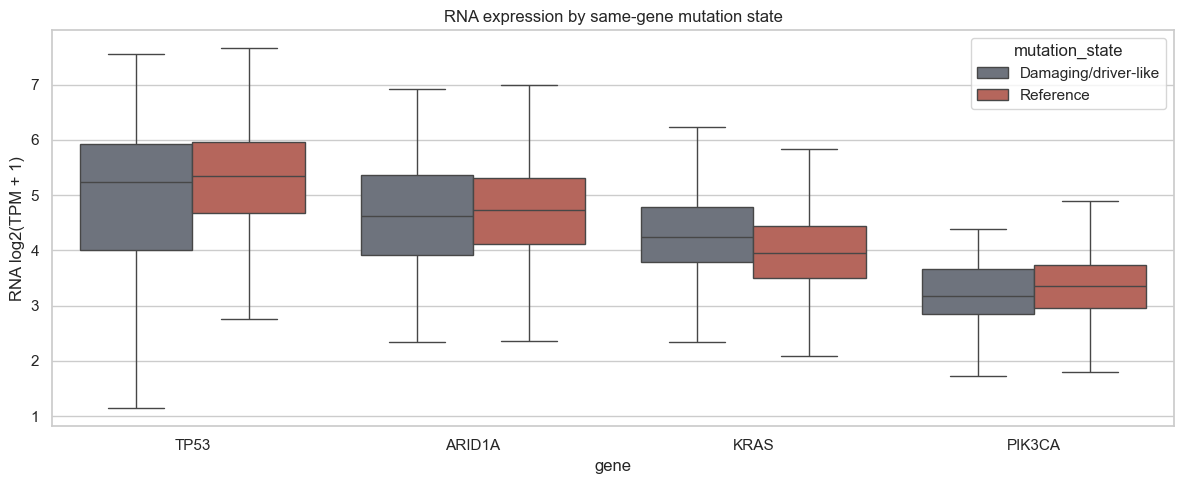

In [6]:
mutation_rna_ids = sorted(cohort_ids['Mutation context to RNA'] & set(rna.index))
mutation_by_gene = {gene: set(group['model_id']) for gene, group in mutations.groupby('hugo_symbol')}
damaging_by_gene = {gene: set(group.loc[group['damaging_event'] | group['driver_like_event'], 'model_id']) for gene, group in mutations.groupby('hugo_symbol')}


def rank_biserial(altered: np.ndarray, reference: np.ndarray) -> float:
    altered = np.asarray(altered, dtype=float)
    reference = np.asarray(reference, dtype=float)
    if len(altered) == 0 or len(reference) == 0:
        return np.nan
    ranks = rankdata(np.concatenate([altered, reference]))
    u_altered = ranks[:len(altered)].sum() - len(altered) * (len(altered) + 1) / 2
    return 2 * u_altered / (len(altered) * len(reference)) - 1


def mutation_rna_effect(gene: str, altered_ids: set, definition: str) -> dict:
    frame = pd.DataFrame({
        'rna': rna.loc[mutation_rna_ids, gene],
        'lineage': lineage_lookup.reindex(mutation_rna_ids),
    }).dropna()
    frame['altered'] = frame.index.isin(altered_ids)
    altered = frame.loc[frame['altered'], 'rna'].to_numpy()
    reference = frame.loc[~frame['altered'], 'rna'].to_numpy()
    keep = frame.groupby('lineage')['rna'].transform('size').ge(15)
    adjusted = frame.loc[keep].copy()
    adjusted['rna_residual'] = adjusted['rna'] - adjusted.groupby('lineage')['rna'].transform('median')
    altered_adjusted = adjusted.loc[adjusted['altered'], 'rna_residual'].to_numpy()
    reference_adjusted = adjusted.loc[~adjusted['altered'], 'rna_residual'].to_numpy()
    return {
        'gene': gene,
        'alteration_definition': definition,
        'altered_models': len(altered),
        'reference_models': len(reference),
        'median_rna_altered': np.median(altered) if len(altered) else np.nan,
        'median_rna_reference': np.median(reference) if len(reference) else np.nan,
        'median_rna_difference': np.median(altered) - np.median(reference) if len(altered) and len(reference) else np.nan,
        'rank_biserial_effect': rank_biserial(altered, reference),
        'altered_models_lineage_adjusted': len(altered_adjusted),
        'reference_models_lineage_adjusted': len(reference_adjusted),
        'lineage_adjusted_rank_biserial': rank_biserial(altered_adjusted, reference_adjusted),
    }


mutation_effect_rows = []
for gene in analysis_gene_table['symbol']:
    mutation_effect_rows.append(mutation_rna_effect(gene, mutation_by_gene.get(gene, set()), 'Any recorded variant'))
    mutation_effect_rows.append(mutation_rna_effect(gene, damaging_by_gene.get(gene, set()), 'Damaging or driver-like'))
mutation_rna_results = pd.DataFrame(mutation_effect_rows)
mutation_rna_usable = mutation_rna_results.loc[
    mutation_rna_results['altered_models'].ge(10)
    & mutation_rna_results['reference_models'].ge(10)
    & mutation_rna_results['altered_models_lineage_adjusted'].ge(10)
    & mutation_rna_results['reference_models_lineage_adjusted'].ge(10)
].copy()

display(mutation_rna_usable.sort_values('lineage_adjusted_rank_biserial').head(25))
display(mutation_rna_usable.sort_values('lineage_adjusted_rank_biserial', ascending=False).head(25))
display(mutation_rna_results.loc[mutation_rna_results['gene'].isin(PROJECT_GENES)].sort_values(['gene', 'alteration_definition']))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=mutation_rna_usable, x='altered_models', y='lineage_adjusted_rank_biserial', hue='alteration_definition', alpha=0.7, ax=axes[0])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Mutation-associated RNA effects and group size')
plot_examples = mutation_rna_usable.loc[
    mutation_rna_usable['gene'].isin(PROJECT_GENES)
    & mutation_rna_usable['alteration_definition'].eq('Damaging or driver-like')
].sort_values('lineage_adjusted_rank_biserial')
sns.barplot(data=plot_examples, x='gene', y='lineage_adjusted_rank_biserial', color='#c45b4d', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Project genes: damaging/driver-like mutation effect')
plt.tight_layout()
plt.show()

boxplot_genes = [gene for gene in ['TP53', 'ARID1A', 'KRAS', 'PIK3CA'] if gene in rna.columns]
box_rows = []
for gene in boxplot_genes:
    values = rna.loc[mutation_rna_ids, gene]
    altered_ids = damaging_by_gene.get(gene, set())
    box_rows.append(pd.DataFrame({'gene': gene, 'rna': values.values, 'mutation_state': np.where(values.index.isin(altered_ids), 'Damaging/driver-like', 'Reference')}))
box_long = pd.concat(box_rows, ignore_index=True)
plt.figure(figsize=(12, 5))
sns.boxplot(data=box_long, x='gene', y='rna', hue='mutation_state', showfliers=False, palette=['#6b7280', '#c45b4d'])
plt.title('RNA expression by same-gene mutation state')
plt.ylabel('RNA log2(TPM + 1)')
plt.tight_layout()
plt.show()

### What this means for the project

A negative effect means altered models tend to have lower RNA for that same gene; this can be compatible with loss-of-function biology, but sequence changes do not always reduce transcript abundance. Oncogene hotspots can preserve or increase expression, while passenger variants may have little effect.

The rank-biserial effect compares the full altered and reference distributions. Values near zero indicate heavy overlap; values closer to -1 or 1 indicate stronger separation. It is still an association, not proof that the mutation caused the RNA change.

**Example:** classifying every TP53 variant as equivalent can mix damaging mutations with variants of uncertain consequence. The two-definition table shows how the conclusion changes when the alteration rule becomes biologically narrower.

## 6. RNA to protein concordance

The primary RNA-protein analysis uses well-measured, one-to-one protein features. Protein missingness is handled pairwise for each gene, so every correlation reports its own model denominator.

,count,mean,std,min,25%,50%,75%,max
models_with_both,779.0,309.323492,83.348731,103.000000,255.000000,361.000000,370.000000,370.000000
spearman_rho,779.0,0.442112,0.223219,-0.172667,0.304273,0.454011,0.609393,0.870195
models_lineage_adjusted,779.0,209.299101,83.835416,0.000000,151.000000,265.000000,270.000000,270.000000
lineage_adjusted_rho,745.0,0.417620,0.210160,-0.334017,0.288647,0.435790,0.566538,0.848790


,gene,protein_feature,models_with_both,spearman_rho,models_lineage_adjusted,lineage_adjusted_rho
758,PLLP,Q9Y342 (PLLP),117,0.863129,31,0.848790
181,MCAM,P43121 (MCAM),370,0.870195,270,0.841555
100,ERAP2,Q6P179 (ERAP2),370,0.830194,270,0.840064
676,GNG4,P50150 (GNG4),184,0.725238,59,0.829866
220,NT5E,P21589 (NT5E),370,0.860600,270,0.826646
559,CAMK1,Q14012 (CAMK1),281,0.839525,161,0.816139
656,NPNT,Q6UXI9 (NPNT),202,0.717830,104,0.809554
420,CD40,P25942 (CD40),352,0.846247,254,0.806355
771,POU3F2,P20265 (POU3F2),113,0.651690,31,0.803958
395,HSPB8,Q9UJY1 (HSPB8),361,0.848883,264,0.802090


,gene,protein_feature,models_with_both,spearman_rho,models_lineage_adjusted,lineage_adjusted_rho
690,DCHS2,Q6V1P9 (DCHS2),174,-0.113729,54,-0.334017
728,ZNF568,Q3ZCX4 (ZNF568),140,-0.104443,32,-0.214849
654,DNAH3,Q8TD57 (DNAH3),203,0.019459,108,-0.197681
753,USH2A,O75445-3 (USH2A),124,0.054346,50,-0.185387
542,CCDC57,Q2TAC2 (CCDC57),290,-0.172667,199,-0.185058
150,INTS12,Q96CB8 (INTS12),370,-0.115151,270,-0.177728
658,SERPINF2,P08697 (SERPINF2),202,0.024922,110,-0.161550
704,PALB2,Q86YC2 (PALB2),158,0.198589,32,-0.129044
646,RXRG,P48443 (RXRG),205,-0.147177,117,-0.128372
710,SPTA1,P02549 (SPTA1),150,0.032848,37,-0.120213


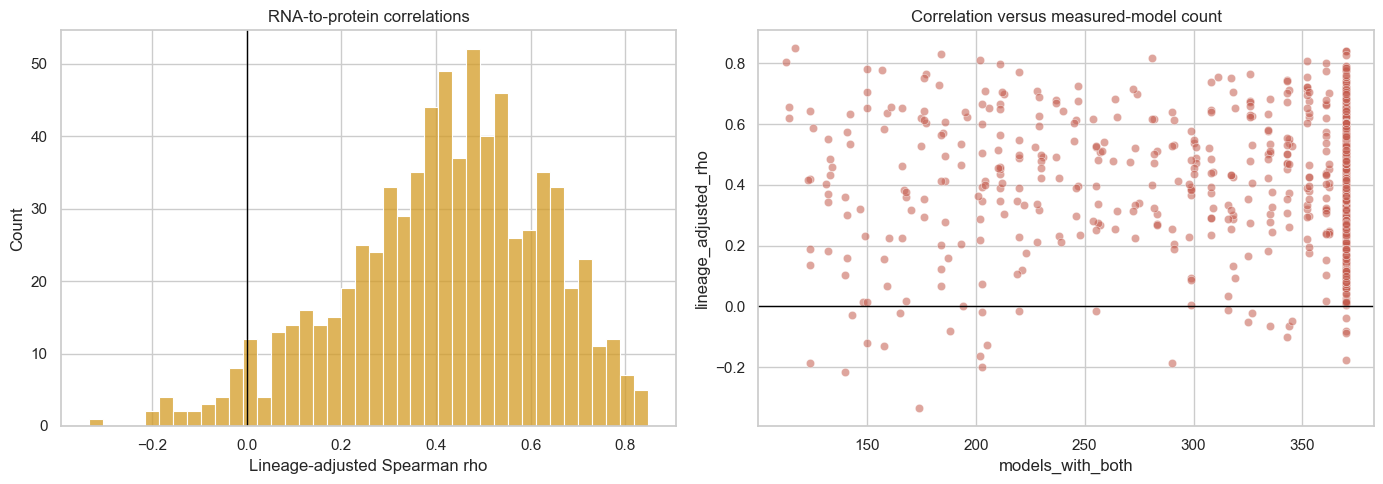

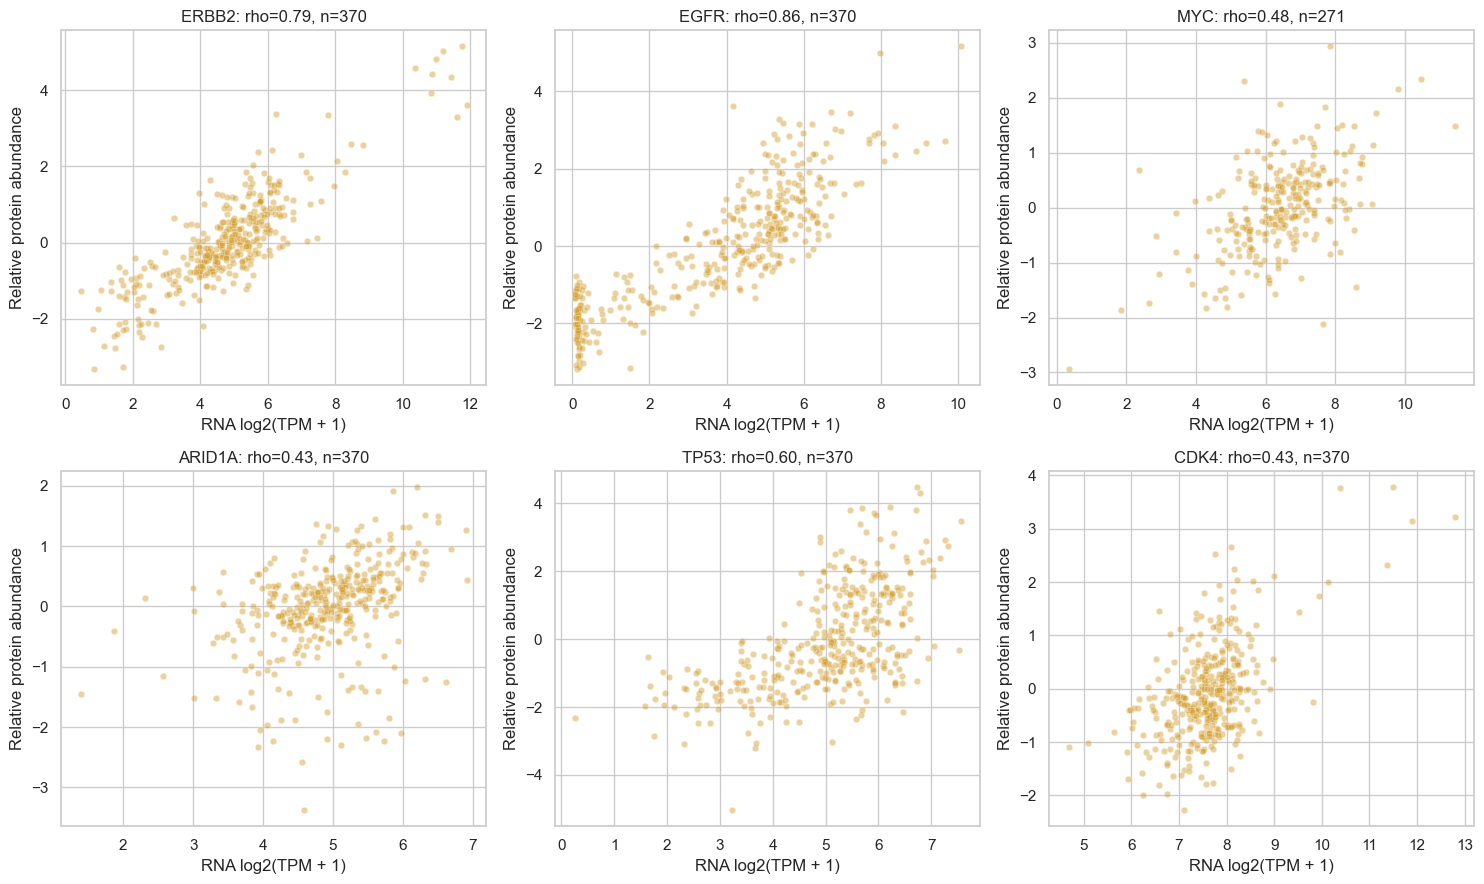

In [7]:
protein_candidates = primary_protein_map.loc[
    primary_protein_map['measured_models'].ge(100)
    & primary_protein_map['symbol'].isin(rna.columns)
].sort_values(['measured_models', 'symbol'], ascending=[False, True])
protein_analysis_genes = protein_candidates['symbol'].tolist()
protein_feature_by_gene = protein_candidates.set_index('symbol')['protein_feature'].to_dict()

protein_subset = proteomics[['model_id', *[protein_feature_by_gene[g] for g in protein_analysis_genes]]].rename(
    columns={protein_feature_by_gene[g]: g for g in protein_analysis_genes}
).set_index('model_id')
rna_protein_ids = sorted(cohort_ids['RNA to protein'] & set(rna.index) & set(protein_subset.index))

rna_protein_rows = []
for gene in protein_analysis_genes:
    result = correlation_with_lineage_adjustment(rna.loc[rna_protein_ids, gene], protein_subset.loc[rna_protein_ids, gene], minimum_lineage_size=15)
    rna_protein_rows.append({'gene': gene, 'protein_feature': protein_feature_by_gene[gene], **result})
rna_protein_results = pd.DataFrame(rna_protein_rows)

display(rna_protein_results[['models_with_both', 'spearman_rho', 'models_lineage_adjusted', 'lineage_adjusted_rho']].describe().T)
display(rna_protein_results.nlargest(25, 'lineage_adjusted_rho'))
display(rna_protein_results.nsmallest(25, 'lineage_adjusted_rho'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(rna_protein_results['lineage_adjusted_rho'].dropna(), bins=40, color='#d39b24', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('RNA-to-protein correlations')
axes[0].set_xlabel('Lineage-adjusted Spearman rho')
sns.scatterplot(data=rna_protein_results, x='models_with_both', y='lineage_adjusted_rho', alpha=0.55, color='#c45b4d', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Correlation versus measured-model count')
plt.tight_layout()
plt.show()

example_protein_genes = [gene for gene in ['ERBB2', 'EGFR', 'MYC', 'ARID1A', 'TP53', 'CDK4'] if gene in protein_analysis_genes]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, gene in zip(axes.flat, example_protein_genes):
    frame = pd.DataFrame({'rna': rna.loc[rna_protein_ids, gene], 'protein': protein_subset.loc[rna_protein_ids, gene]}).dropna()
    sns.scatterplot(data=frame, x='rna', y='protein', alpha=0.45, s=22, color='#d39b24', ax=ax)
    ax.set_title(f'{gene}: rho={frame.rna.corr(frame.protein, method="spearman"):.2f}, n={len(frame):,}')
    ax.set_xlabel('RNA log2(TPM + 1)'); ax.set_ylabel('Relative protein abundance')
for ax in axes.flat[len(example_protein_genes):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

### What this means for the project

RNA-protein agreement varies by gene because translation and protein degradation add another layer of regulation. Protein measurements also contain gene-specific missingness, so two genes can have different denominators even inside the same 370-model cohort.

A high RNA-protein correlation makes an RNA-derived explanation more biologically convincing. A low correlation does not prove the RNA measurement is wrong; it can indicate post-transcriptional regulation or technical limitations.

**Example:** if Gene B appears highly expressed at RNA level but its protein is not detected or does not track RNA, a dashboard should describe the RNA evidence and protein uncertainty separately.

## 7. Copy number to RNA to protein on the same models

The strict chain analysis uses the same models for all three measurements of a gene. This prevents apparently consistent pairwise results from being calculated on different cell-line cohorts.

,count,mean,std,min,25%,50%,75%,max
triple_measured_models,779.0,239.605905,64.947101,75.000000,194.000000,281.000000,287.000000,287.000000
copy_rna_rho,779.0,0.237834,0.136896,-0.239945,0.151838,0.243037,0.331840,0.571302
rna_protein_rho,779.0,0.438081,0.226982,-0.219284,0.297272,0.448873,0.601584,0.884662
copy_protein_rho,779.0,0.129199,0.122097,-0.369506,0.051609,0.126886,0.209235,0.454196


,gene,triple_measured_models,copy_rna_rho,rna_protein_rho,copy_protein_rho,directionally_consistent
218,ERGIC3,287,0.571302,0.330854,0.275651,True
148,CPNE1,287,0.544658,0.588910,0.302372,True
639,SNRPB,287,0.540218,0.080377,-0.080947,True
258,GDI2,287,0.532949,0.570234,0.324008,True
490,PEMT,90,0.528817,0.570427,0.423057,True
145,COX16,217,0.528252,0.376260,0.276692,True
666,TARS1,287,0.521913,0.461006,0.184390,True
33,AP5S1,248,0.521392,0.252402,0.208360,True
220,ESS2,287,0.520820,0.306111,0.173051,True
691,TNKS,224,0.519873,0.321066,0.246858,True


,gene,triple_measured_models,copy_rna_rho,rna_protein_rho,copy_protein_rho,directionally_consistent
42,ARID1A,287,0.176357,0.487508,0.101392,True
81,BRAF,280,0.222075,0.291796,0.159118,True
82,BRCA1,287,0.200474,0.221586,0.082172,True
83,BRCA2,232,0.318575,0.191151,0.091050,True
121,CDK4,287,0.239981,0.425428,0.098125,True
206,EGFR,287,0.423658,0.870519,0.383425,True
211,EML4,287,0.182001,0.629673,0.088070,True
216,ERBB2,287,0.283413,0.806059,0.221922,True
223,EZH2,287,0.156568,0.318614,-0.022395,True
345,KRAS,238,0.418935,0.293968,0.413019,True


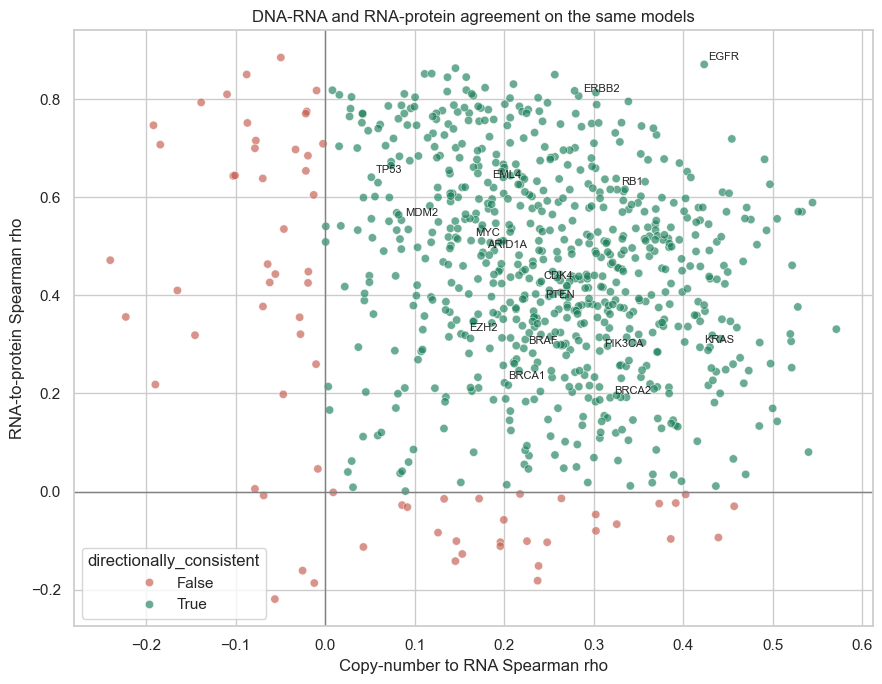

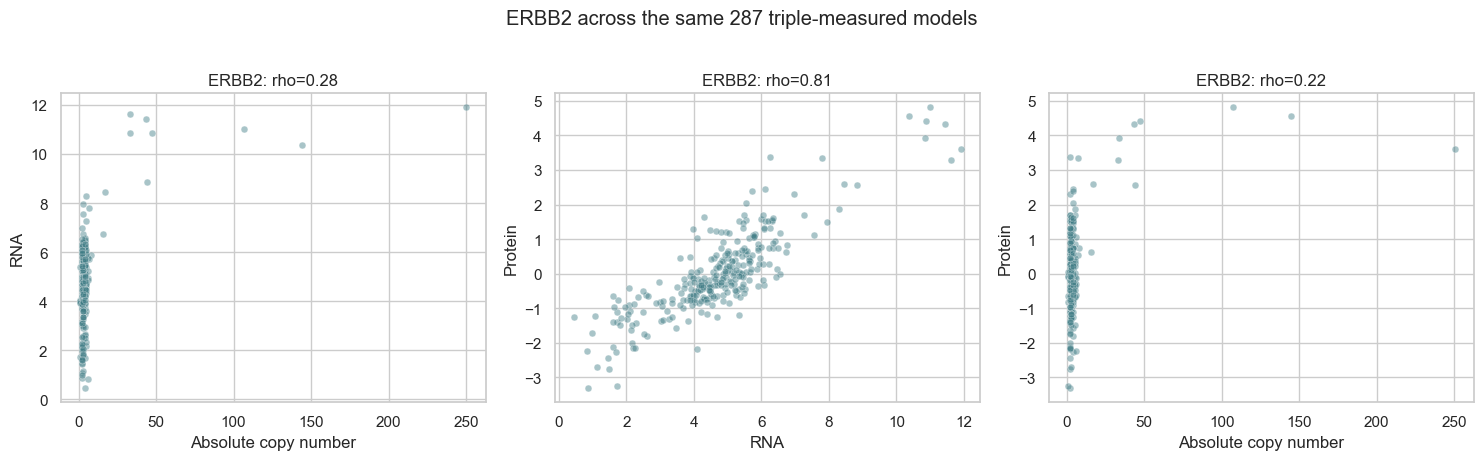

In [8]:
triple_ids = sorted(cohort_ids['Copy number to RNA to protein'] & set(rna.index) & set(copy_number.index) & set(protein_subset.index))
triple_genes = sorted(set(protein_analysis_genes) & set(copy_number.columns))
triple_rows = []
for gene in triple_genes:
    frame = pd.DataFrame({
        'copy_number': copy_number.loc[triple_ids, gene],
        'rna': rna.loc[triple_ids, gene],
        'protein': protein_subset.loc[triple_ids, gene],
    }).dropna()
    if len(frame) < 30:
        continue
    copy_rna_rho = frame['copy_number'].corr(frame['rna'], method='spearman')
    rna_protein_rho = frame['rna'].corr(frame['protein'], method='spearman')
    copy_protein_rho = frame['copy_number'].corr(frame['protein'], method='spearman')
    triple_rows.append({
        'gene': gene,
        'triple_measured_models': len(frame),
        'copy_rna_rho': copy_rna_rho,
        'rna_protein_rho': rna_protein_rho,
        'copy_protein_rho': copy_protein_rho,
        'directionally_consistent': bool(copy_rna_rho > 0 and rna_protein_rho > 0),
    })
triple_results = pd.DataFrame(triple_rows)

display(triple_results[['triple_measured_models', 'copy_rna_rho', 'rna_protein_rho', 'copy_protein_rho']].describe().T)
display(triple_results.loc[triple_results['directionally_consistent']].sort_values(['copy_rna_rho', 'rna_protein_rho'], ascending=False).head(30))
display(triple_results.loc[triple_results['gene'].isin(PROJECT_GENES)].sort_values('gene'))

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=triple_results, x='copy_rna_rho', y='rna_protein_rho', hue='directionally_consistent', palette={True: '#1b7f5a', False: '#c45b4d'}, alpha=0.65, ax=ax)
ax.axhline(0, color='grey', linewidth=1); ax.axvline(0, color='grey', linewidth=1)
for _, row in triple_results.loc[triple_results['gene'].isin(PROJECT_GENES)].iterrows():
    ax.annotate(row['gene'], (row['copy_rna_rho'], row['rna_protein_rho']), fontsize=8, xytext=(3, 3), textcoords='offset points')
ax.set_title('DNA-RNA and RNA-protein agreement on the same models')
ax.set_xlabel('Copy-number to RNA Spearman rho')
ax.set_ylabel('RNA-to-protein Spearman rho')
plt.tight_layout()
plt.show()

chain_example = next((gene for gene in ['ERBB2', 'EGFR', 'MYC', 'CDK4'] if gene in triple_genes), None)
if chain_example:
    chain = pd.DataFrame({
        'copy_number': copy_number.loc[triple_ids, chain_example],
        'rna': rna.loc[triple_ids, chain_example],
        'protein': protein_subset.loc[triple_ids, chain_example],
    }).dropna()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, x, y, x_label, y_label in [
        (axes[0], 'copy_number', 'rna', 'Absolute copy number', 'RNA'),
        (axes[1], 'rna', 'protein', 'RNA', 'Protein'),
        (axes[2], 'copy_number', 'protein', 'Absolute copy number', 'Protein'),
    ]:
        sns.scatterplot(data=chain, x=x, y=y, alpha=0.45, s=24, color='#3f7c85', ax=ax)
        ax.set_title(f'{chain_example}: rho={chain[x].corr(chain[y], method="spearman"):.2f}')
        ax.set_xlabel(x_label); ax.set_ylabel(y_label)
    fig.suptitle(f'{chain_example} across the same {len(chain):,} triple-measured models', y=1.02)
    plt.tight_layout()
    plt.show()

### What this means for the project

Genes in the upper-right part of the concordance plot have positive copy-number-to-RNA and RNA-to-protein relationships on the same models. This is a transparent description of cross-layer consistency, not a causal path or a hidden score.

The end-to-end copy-number-to-protein correlation is shown separately because RNA may only partly transmit the relationship. Formal mediation would require stronger assumptions and is outside this EDA.

**Example:** if ERBB2 copy number, RNA, and protein all rise together, the dashboard can explain that the alteration is visible at three biological layers. A later dependency analysis must still test whether this context changes sensitivity to another gene.

## 8. Feature-engineering candidates and decisions

Only stable, interpretable statistics should move forward. This section records what each candidate means and what must accompany it.

In [9]:
feature_candidates = pd.DataFrame([
    {'candidate_feature': 'copy_rna_spearman', 'biological_meaning': 'DNA dosage and RNA move together for the same gene', 'required_context': 'models_with_both, lineage-adjusted value', 'status': 'Primary 24Q4 candidate'},
    {'candidate_feature': 'copy_rna_lineage_adjusted_spearman', 'biological_meaning': 'Dosage-RNA agreement beyond broad tissue medians', 'required_context': 'models_lineage_adjusted and lineage rule', 'status': 'Primary 24Q4 candidate'},
    {'candidate_feature': 'mutation_rna_rank_biserial', 'biological_meaning': 'RNA distribution differs between altered and reference models', 'required_context': 'alteration definition and both group sizes', 'status': 'Definition-sensitive candidate'},
    {'candidate_feature': 'rna_protein_spearman', 'biological_meaning': 'RNA evidence is reflected at protein level', 'required_context': 'protein feature, measured models, release label', 'status': 'Supplementary validation'},
    {'candidate_feature': 'directionally_consistent_chain', 'biological_meaning': 'Copy-RNA and RNA-protein correlations are both positive', 'required_context': 'three correlations and triple-measured denominator', 'status': 'Explanation flag only'},
])

decisions = pd.DataFrame([
    {'decision': 'Gene identity', 'rule': 'Use gene_master columns; require UniProt-symbol agreement for primary protein mapping.'},
    {'decision': 'Copy-number statistics', 'rule': 'Report raw and lineage-adjusted Spearman rho with exact model counts.'},
    {'decision': 'Mutation reference group', 'rule': 'Use only mutation-assayed models and retain alteration-definition sensitivity.'},
    {'decision': 'Protein evidence', 'rule': 'Treat as supplementary because the release is not matched to 24Q4.'},
    {'decision': 'Triple-layer result', 'rule': 'Calculate all three relationships on the same models and avoid causal language.'},
    {'decision': 'Missing values', 'rule': 'Use pairwise measured denominators; never impute assay absence as zero.'},
    {'decision': 'Feature use', 'rule': 'Keep scoring evidence, confidence context, and dashboard explanation fields separate.'},
])

display(feature_candidates)
display(decisions)

assert copy_rna_results['models_with_both'].le(len(copy_rna_ids)).all()
assert mutation_rna_results['altered_models'].add(mutation_rna_results['reference_models']).eq(len(mutation_rna_ids)).all()
assert rna_protein_results['models_with_both'].le(len(rna_protein_ids)).all()
assert triple_results['triple_measured_models'].le(len(triple_ids)).all()

,candidate_feature,biological_meaning,required_context,status
0,copy_rna_spearman,DNA dosage and RNA move together for the same ...,"models_with_both, lineage-adjusted value",Primary 24Q4 candidate
1,copy_rna_lineage_adjusted_spearman,Dosage-RNA agreement beyond broad tissue medians,models_lineage_adjusted and lineage rule,Primary 24Q4 candidate
2,mutation_rna_rank_biserial,RNA distribution differs between altered and r...,alteration definition and both group sizes,Definition-sensitive candidate
3,rna_protein_spearman,RNA evidence is reflected at protein level,"protein feature, measured models, release label",Supplementary validation
4,directionally_consistent_chain,Copy-RNA and RNA-protein correlations are both...,three correlations and triple-measured denomin...,Explanation flag only


,decision,rule
0,Gene identity,Use gene_master columns; require UniProt-symbo...
1,Copy-number statistics,Report raw and lineage-adjusted Spearman rho w...
2,Mutation reference group,Use only mutation-assayed models and retain al...
3,Protein evidence,Treat as supplementary because the release is ...
4,Triple-layer result,Calculate all three relationships on the same ...
5,Missing values,Use pairwise measured denominators; never impu...
6,Feature use,"Keep scoring evidence, confidence context, and..."


### What this means for the project

The strongest feature candidates are not single unexplained numbers. Every value travels with its denominator, lineage adjustment, alteration rule, identifier mapping, and release status.

This notebook prepares the molecular context for the next cross-layer step: testing whether mutation, copy number, RNA, or signatures in **Gene A** are associated with CRISPR dependency on **Gene B**. That is where cross-layer concordance begins contributing directly to explainable gene-pair prediction.